In [1]:
import cupy as cp

CuPy is a GPU array backend that implements a subset of NumPy interface. The main difference between numpy and Cupy is that Numpy is designed to work with data stored in the CPU memory and Cupy - int the GPU.

When performing computations, CuPy automatically handles data transfers between the CPU and GPU, ensuring a seamless workflow. When an array is created or modified in CuPy, it resides in GPU memory.

In [11]:
def saxpy(x,y,alpha):
    z = x + alpha * y
    return z

In [25]:
cpu = np.array([])
gpu = np.array([])

for i in range(0,1000000,50000):
    x_gpu = cp.random.rand(i)
    y_gpu = cp.random.rand(i)

    x_cpu = np.random.rand(i)
    y_cpu = np.random.rand(i)

    alpha_gpu = cp.random.rand()
    alpha_cpu = np.random.rand()

    time_cpu = %timeit -o -r 2 saxpy(x_cpu, y_cpu, alpha_cpu)
    time_gpu = %timeit -o -r 2 saxpy(x_gpu, y_gpu, alpha_gpu)

    cpu = np.append(cpu, time_cpu.average)
    gpu = np.append(gpu, time_gpu.average)



4.74 µs ± 1.72 µs per loop (mean ± std. dev. of 2 runs, 100000 loops each)
8.78 µs ± 204 ns per loop (mean ± std. dev. of 2 runs, 100000 loops each)
44.6 µs ± 748 ns per loop (mean ± std. dev. of 2 runs, 10000 loops each)
27.1 µs ± 1.21 µs per loop (mean ± std. dev. of 2 runs, 10000 loops each)
118 µs ± 819 ns per loop (mean ± std. dev. of 2 runs, 10000 loops each)
25.5 µs ± 236 ns per loop (mean ± std. dev. of 2 runs, 10000 loops each)
236 µs ± 10.4 µs per loop (mean ± std. dev. of 2 runs, 1000 loops each)
40.9 µs ± 1.18 µs per loop (mean ± std. dev. of 2 runs, 10000 loops each)
287 µs ± 322 ns per loop (mean ± std. dev. of 2 runs, 1000 loops each)
33.1 µs ± 5.09 µs per loop (mean ± std. dev. of 2 runs, 10000 loops each)
310 µs ± 2.17 µs per loop (mean ± std. dev. of 2 runs, 1000 loops each)
36.3 µs ± 322 ns per loop (mean ± std. dev. of 2 runs, 10000 loops each)
387 µs ± 4.33 µs per loop (mean ± std. dev. of 2 runs, 1000 loops each)
44.9 µs ± 14.4 ns per loop (mean ± std. dev. of 2 r

Text(0, 0.5, 'time')

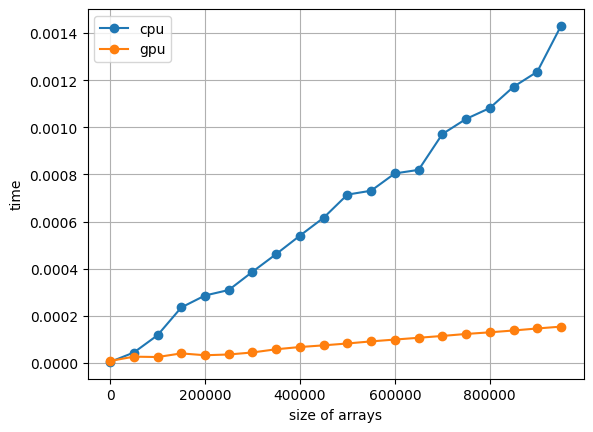

In [31]:
plt.figure()
plt.plot(range(0,1000000,50000),  cpu,'-o', label = 'cpu')
plt.plot(range(0,1000000,50000),  gpu,'-o', label = 'gpu')

plt.legend()
plt.grid()
plt.xlabel('size of arrays')
plt.ylabel('time')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [50]:
def bifurcation_1(r, X):
    for m in range(1,200):
        X = r * X * (1 - X)
    return X

In [51]:
def bif(R, array, X):
    for ind,r in enumerate(R):
        # print('hi')
        for n in range(200):
            array[ind, n] = bifurcation_1(r, X)

    return array

In [53]:
cpu = np.array([])
gpu = np.array([])

for num in range(0,200,50):
    R_cpu = np.linspace(0,4,num)
    R_gpu = cp.linspace(0,4,num)
    array_cpu = np.empty((num, 200))
    array_gpu = cp.empty((num, 200))

    X_cpu = 0.5
    X_gpu = cp.array(0.5)

    time_cpu = %timeit -o -r 1 bif(R_cpu, array_cpu, X_cpu)
    time_gpu = %timeit -o -r 1 bif(R_gpu, array_gpu, X_gpu)

    cpu = np.append(cpu, time_cpu.average)
    gpu = np.append(gpu, time_gpu.average)


1.17 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000000 loops each)
764 ns ± 0 ns per loop (mean ± std. dev. of 1 run, 1000000 loops each)
467 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
1min 36s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
751 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
3min 6s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
1.17 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
4min 37s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


Text(0, 0.5, 'time')

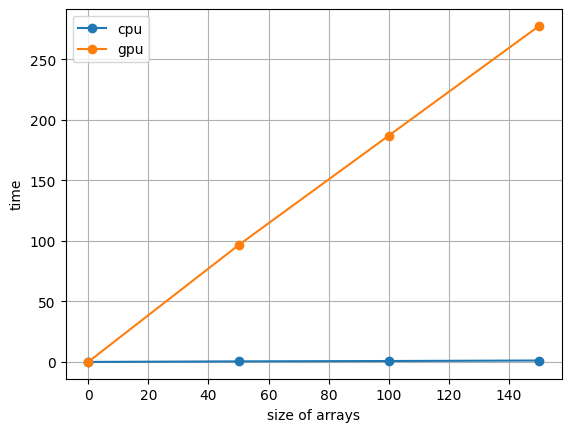

In [57]:
plt.figure()
plt.plot(range(0,200,50),  cpu,'-o', label = 'cpu')
plt.plot(range(0,200,50),  gpu,'-o', label = 'gpu')

plt.legend()
plt.grid()
plt.xlabel('size of arrays')
plt.ylabel('time')

As you see, using cupy computation time increased significantly. It is interesting and not clear, why is it so..